<a href="https://colab.research.google.com/github/MexicoHamburger/AIP-2/blob/main/so_survey2024_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stack Overflow Developer Survey 2024 – Career Graph EDA ✨

이 노트북은 **Stack Overflow Annual Developer Survey 2024** CSV(필드 리스트는 문제 지시문 참고)를 업로드한 뒤,  
**커리어 그래프 구축에 유용한 핵심 통계·패턴**을 탐색합니다.

> ⚙️ **사용 방법**  
> 1. 첫 번째 코드 셀을 실행해 CSV를 업로드하세요. (`files.upload()` 사용)  
> 2. 순서대로 셀을 실행하며 EDA 결과를 확인합니다.  

각 코드 셀 위에는 **“이 셀에서 얻고자 하는 정보”**를 마크다운으로 명시했습니다.


In [1]:
# 📚 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


## 1️⃣ CSV 업로드  
- `files.upload()` 위젯을 통해 **`survey_results_public_2024.csv`** 등을 업로드합니다.  
- 업로드가 완료되면 DataFrame `df` 로드 및 Shape·Head 출력.

In [2]:
# CSV 업로드 (Colab)
uploaded = files.upload()
for fname, content in uploaded.items():
    print(f"✅ {fname} uploaded — size: {len(content):,} bytes")
    df = pd.read_csv(io.BytesIO(content))
    print(f"DataFrame shape: {df.shape}")
    display(df.head())

Saving survey_results_public.csv to survey_results_public.csv
✅ survey_results_public.csv uploaded — size: 159,525,875 bytes
DataFrame shape: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have never visited Stack Overflow or the Sta...,NaN,NaN,NaN,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,NaN,NaN,NaN,Microsoft Teams;Slack,Slack,Slack,NaN,NaN,NaN,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Individual contributor,17.0,Agree,Disagree,Agree,Agree,Agree,Neither agree nor disa

## 2️⃣ 열 정보 & 예시 값  
- 각 열의 **dtype, non‑null 수, 예시 값, Top5 빈도** 또는 **수치 통계**를 표 형태로 확인해,  
  전처리·모델링 시 고려할 사항을 파악합니다.

In [11]:
# 열 요약 표 작성
summary = []
for col in df.columns:
    dtype = df[col].dtype
    non_null = df[col].notna().sum()
    if dtype == object:
        samples = df[col].dropna().unique()[:3]
        top = df[col].value_counts(dropna=True).head(5).to_dict()
        summary.append({
            'Column': col,
            'DType': str(dtype),
            'Non‑Null': non_null,
            'Sample Values': '; '.join(map(str, samples)),
            'Top 5': '; '.join(f'{k}({v})' for k,v in top.items())
        })
    else:
        desc = df[col].describe()
        summary.append({
            'Column': col,
            'DType': str(dtype),
            'Non‑Null': non_null,
            'Sample Values': f"{desc['min']}–{desc['max']}",
            'Top 5': 'N/A'
        })
pd.set_option("display.max_rows", 150)
summary_df = pd.DataFrame(summary)
summary_df

,Column,DType,Non‑Null,Sample Values,Top 5
0,ResponseId,int64,65437,1.0–65437.0,N/A
1,MainBranch,object,65437,I am a developer by profession; I am learning ...,I am a developer by profession(50207); I am no...
2,Age,object,65437,Under 18 years old; 35-44 years old; 45-54 yea...,25-34 years old(23911); 35-44 years old(14942)...
3,Employment,object,65437,"Employed, full-time; Student, full-time; Stude...","Employed, full-time(39041); Independent contra..."
4,RemoteWork,object,54806,"Remote; In-person; Hybrid (some remote, some i...","Hybrid (some remote, some in-person)(23015); R..."
5,Check,object,65437,Apples,Apples(65437)
6,CodingActivities,object,54466,Hobby; Hobby;Contribute to open-source project...,Hobby(9993); I don’t code outside of work(6508...
7,EdLevel,object,60784,Primary/elementary school; Bachelor’s degree (...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)(2..."
8,LearnCode,object,60488,Books / Physical media; Books / Physical media...,"Other online resources (e.g., videos, blogs, f..."
9,LearnCodeOnline,object,49237,Technical documentation;Blogs;Books;Written Tu...,Technical documentation;Blogs;Written Tutorial...


## 3️⃣ 결측치 패턴 시각화  
- 열별 결측 패턴을 Heatmap으로 살펴봅니다.

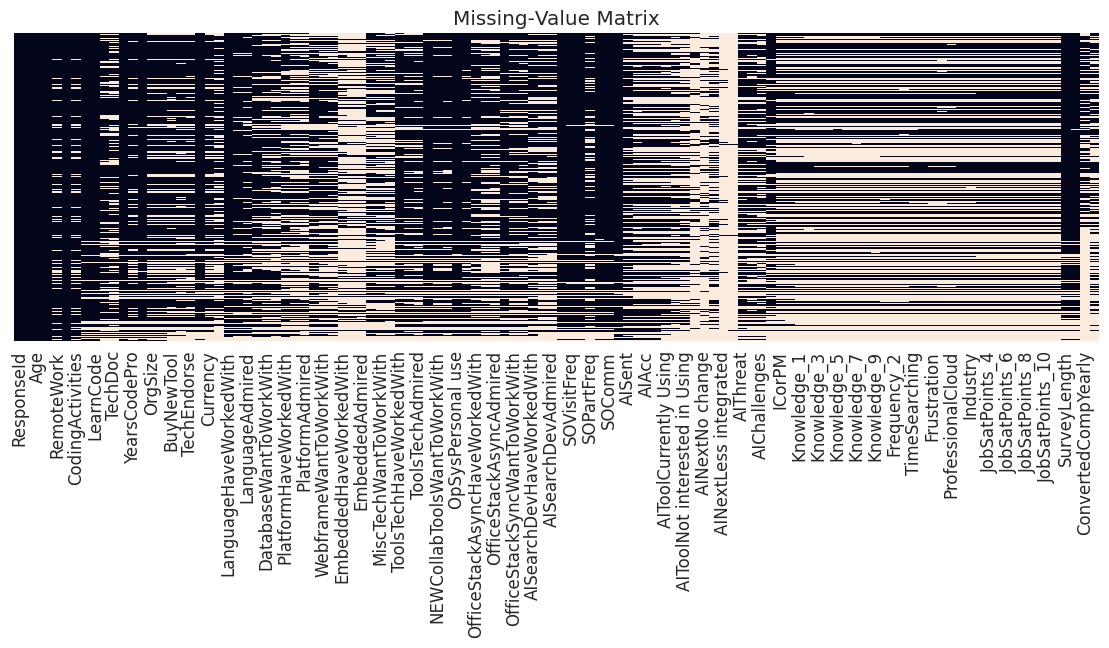

In [4]:
plt.figure(figsize=(14,4))
sns.heatmap(df.isna(), yticklabels=False, cbar=False)
plt.title('Missing‑Value Matrix')
plt.show()

## 4️⃣ 주요 범주형 변수 분포  
- **MainBranch · Employment · DevType · OrgSize · Country** 등 핵심 범주형 변수 Top15 빈도를 확인합니다.

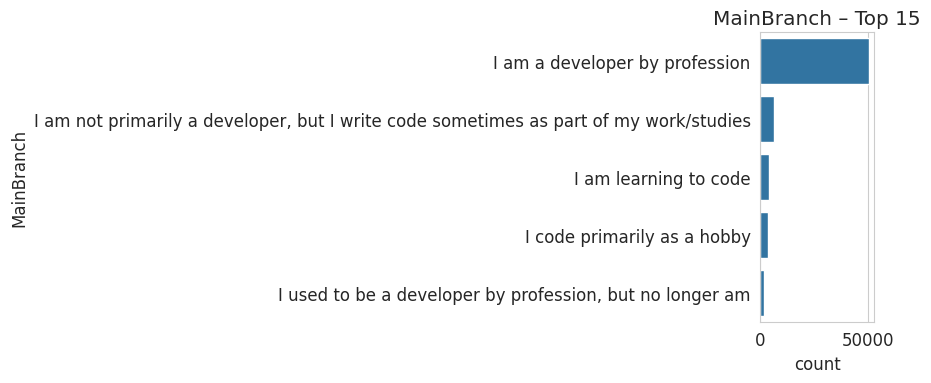

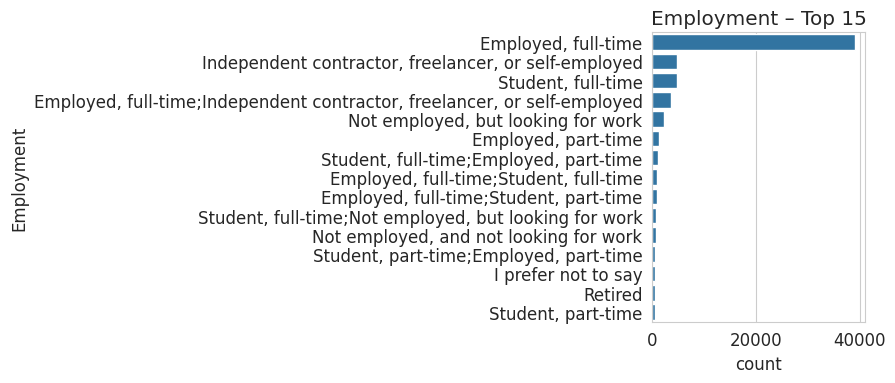

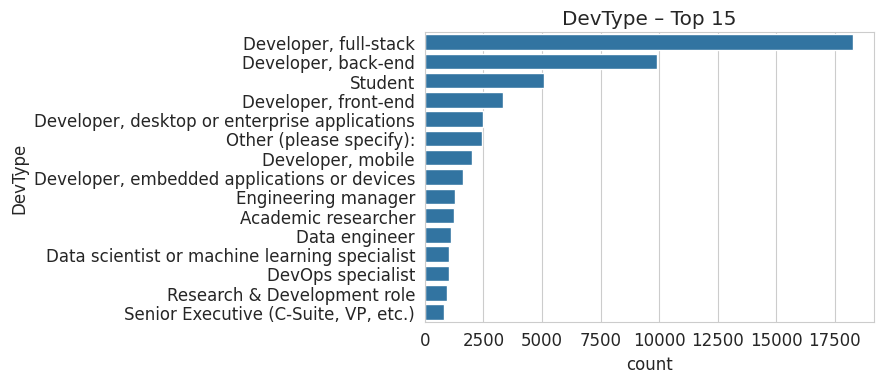

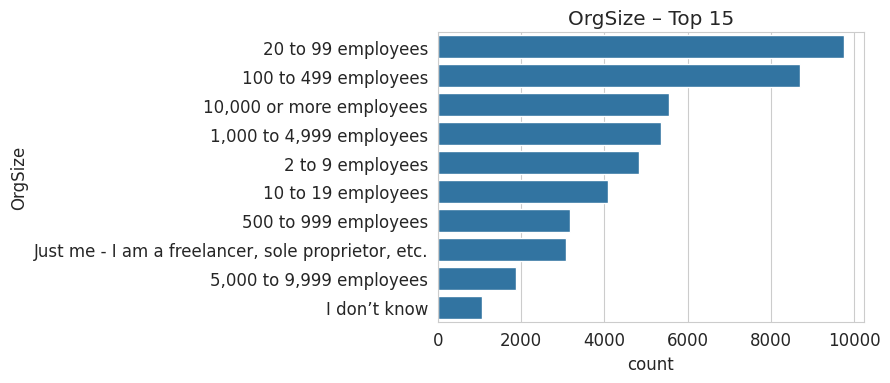

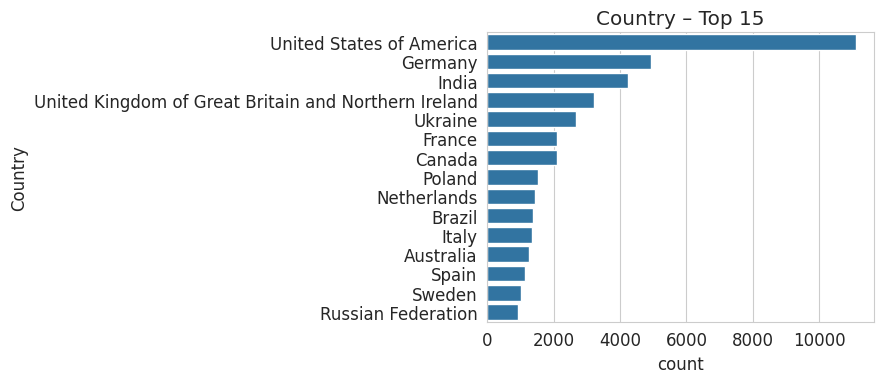

In [5]:
cat_cols = ['MainBranch','Employment','DevType','OrgSize','Country']
for col in cat_cols:
    plt.figure(figsize=(9,4))
    order = df[col].value_counts().head(15).index
    sns.countplot(data=df, y=col, order=order)
    plt.title(f'{col} – Top 15')
    plt.tight_layout()
    plt.show()

## 5️⃣ 주요 수치형 변수 분포  
- **YearsCode, YearsCodePro, ConvertedCompYearly** 히스토그램으로 경력·연봉 분포를 확인합니다.

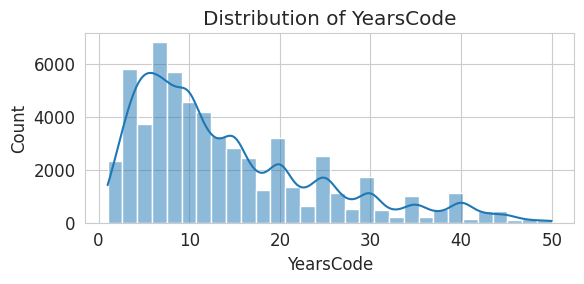

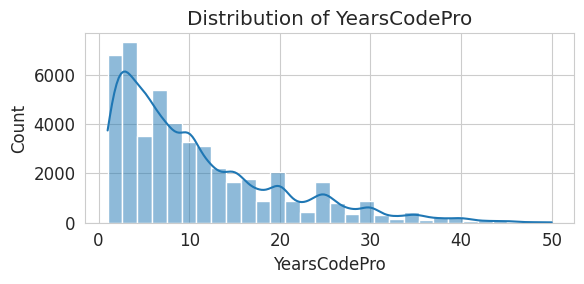

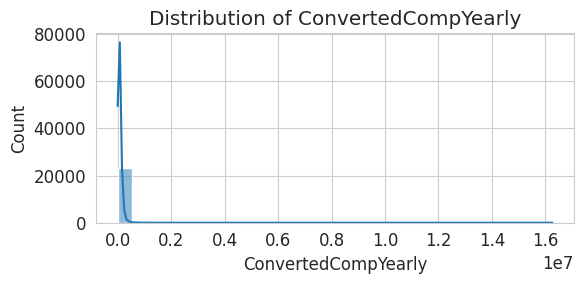

In [6]:
# 문자열일 수 있는 열을 숫자로 변환
for col in ['YearsCode','YearsCodePro','ConvertedCompYearly']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

num_cols = ['YearsCode','YearsCodePro','ConvertedCompYearly']
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

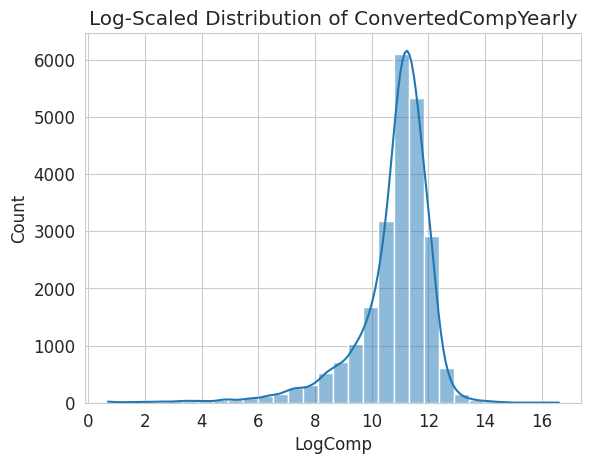

In [12]:
import numpy as np
df['LogComp'] = np.log1p(df['ConvertedCompYearly'])  # log(1 + x)
sns.histplot(df['LogComp'].dropna(), bins=30, kde=True)
plt.title("Log-Scaled Distribution of ConvertedCompYearly")
plt.show()

## 6️⃣ 연봉 vs DevType / Country  
- DevType별, Country별 **평균 연봉(ConvertedCompYearly)** 상위 20개를 시각화하여  
  고임금 포지션·지역을 파악합니다.

,ConvertedCompYearly
DevType,
Hardware Engineer,233049.0
"Senior Executive (C-Suite, VP, etc.)",230558.0
Project manager,213004.0
Developer Experience,162155.0
Blockchain,148709.0
Engineering manager,139143.0
Developer Advocate,130928.0
Cloud infrastructure engineer,120770.0
"Engineer, site reliability",117476.0


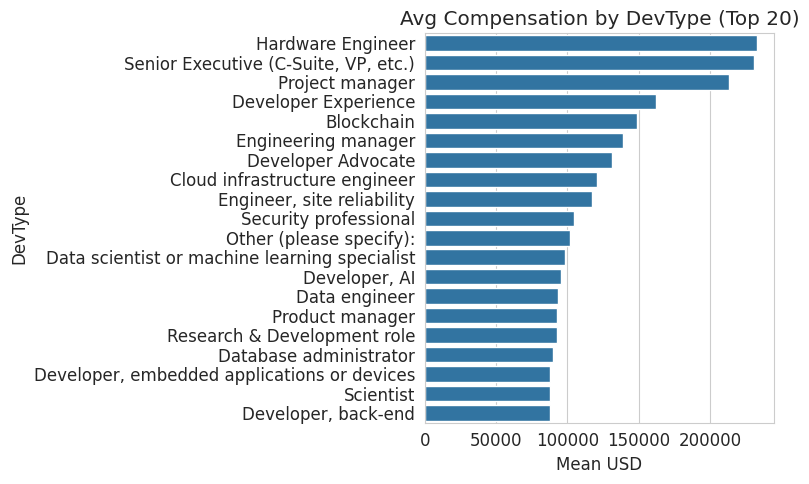

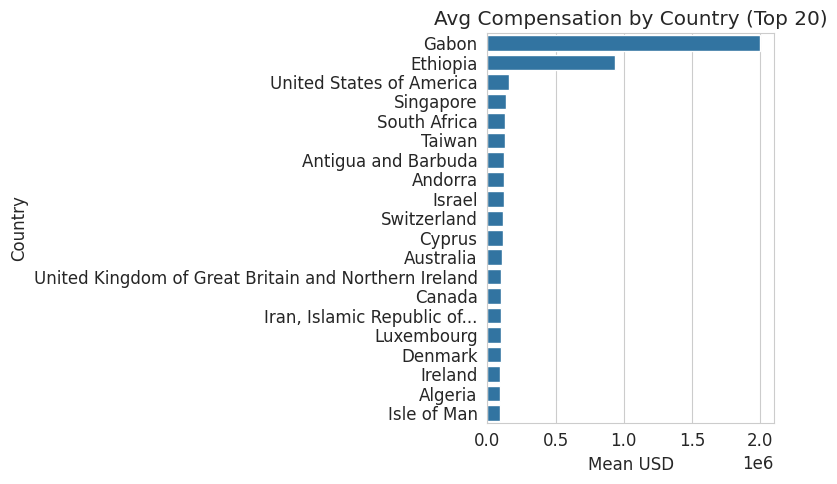

In [7]:
pivot_dev = (df.pivot_table(index='DevType', values='ConvertedCompYearly', aggfunc='mean')
               .sort_values('ConvertedCompYearly', ascending=False).head(20))
display(pivot_dev.round(0))

plt.figure(figsize=(8,5))
sns.barplot(x=pivot_dev['ConvertedCompYearly'], y=pivot_dev.index)
plt.title('Avg Compensation by DevType (Top 20)')
plt.xlabel('Mean USD')
plt.tight_layout()
plt.show()

pivot_cty = (df.pivot_table(index='Country', values='ConvertedCompYearly', aggfunc='mean')
              .sort_values('ConvertedCompYearly', ascending=False).head(20))
plt.figure(figsize=(8,5))
sns.barplot(x=pivot_cty['ConvertedCompYearly'], y=pivot_cty.index)
plt.title('Avg Compensation by Country (Top 20)')
plt.xlabel('Mean USD')
plt.tight_layout()
plt.show()

## 7️⃣ 경력(YearsCodePro) vs 연봉 관계  
- 경력 연차가 연봉에 미치는 영향을 산점도 + 회귀선으로 확인합니다.

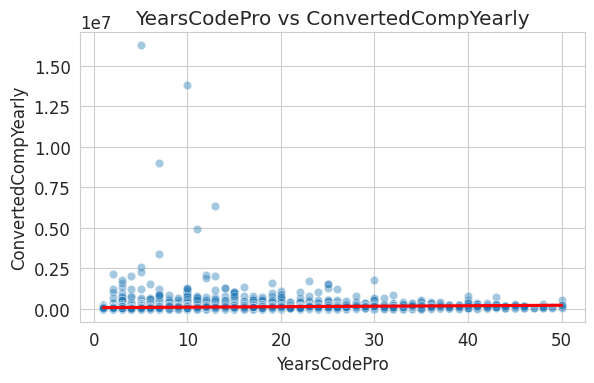

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='YearsCodePro', y='ConvertedCompYearly', alpha=0.4)
sns.regplot(data=df, x='YearsCodePro', y='ConvertedCompYearly', scatter=False, color='red')
plt.title('YearsCodePro vs ConvertedCompYearly')
plt.tight_layout()
plt.show()

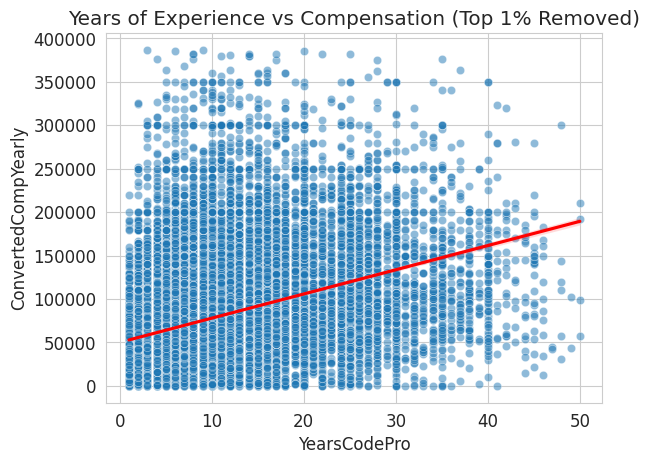

In [13]:
q99 = df['ConvertedCompYearly'].quantile(0.99)
filtered = df[df['ConvertedCompYearly'] < q99]

sns.scatterplot(data=filtered, x='YearsCodePro', y='ConvertedCompYearly', alpha=0.5)
sns.regplot(data=filtered, x='YearsCodePro', y='ConvertedCompYearly', scatter=False, color='red')
plt.title('Years of Experience vs Compensation (Top 1% Removed)')
plt.show()

## 8️⃣ 언어 스택 분석 (LanguageHaveWorkedWith)  
- 다중 선택 열을 전처리해 **상위 사용 언어 Top15** 시각화합니다.

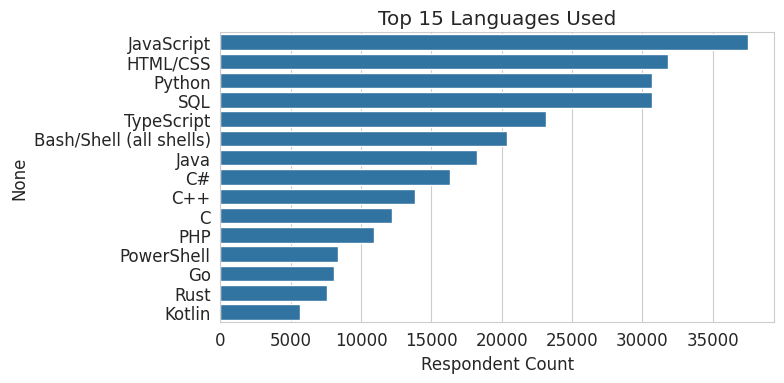

In [9]:
from sklearn.preprocessing import MultiLabelBinarizer
lang_series = df['LanguageHaveWorkedWith'].dropna().apply(lambda x: [s.strip() for s in x.split(';')])
mlb = MultiLabelBinarizer()
lang_mat = mlb.fit_transform(lang_series)
lang_df = pd.DataFrame(lang_mat, columns=mlb.classes_)
top_lang = lang_df.sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(8,4))
sns.barplot(x=top_lang.values, y=top_lang.index)
plt.title('Top 15 Languages Used')
plt.xlabel('Respondent Count')
plt.tight_layout()
plt.show()

## 9️⃣ 범주형 변수 간 연관도 (Cramér’s V)  
- **DevType · Employment · OrgSize · Country** 간 상호 관계 강도를 Heatmap으로 시각화합니다.

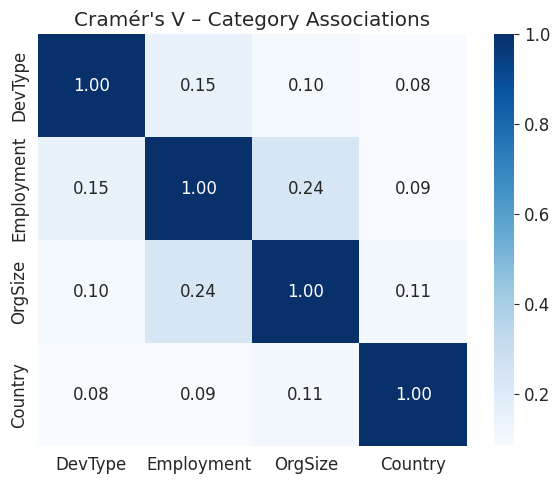

In [10]:
from scipy.stats import chi2_contingency
def cramers_v(col1, col2):
    contingency = pd.crosstab(col1, col2)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1) or 1)))

cats = ['DevType','Employment','OrgSize','Country']
assoc = pd.DataFrame(index=cats, columns=cats, dtype=float)
for i in cats:
    for j in cats:
        assoc.loc[i,j] = cramers_v(df[i], df[j])

plt.figure(figsize=(6,5))
sns.heatmap(assoc, annot=True, fmt='.2f', cmap='Blues')
plt.title("Cramér's V – Category Associations")
plt.tight_layout()
plt.show()

한국인을 대상으로 분석

In [22]:
df_kr = df[
    (df['Country'] == 'South Korea')
].copy()

print(f"전체 응답 수: {len(df):,} → 한국인 응답 수: {len(df_kr):,}")
df_kr.head()

전체 응답 수: 65,437 → 한국인 응답 수: 146


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,LogComp
2232,2233,I am a developer by profession,55-64 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,I don’t code outside of work,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;On the job training;Oth...,Technical documentation;Books;Written Tutorial...,API document(s) and/or SDK document(s);User gu...,35.0,24.0,"Developer, front-end","10,000 or more employees",I have little or no influence,Start a free trial;Ask developers I know/work ...,Is ready-to-go but also customizable for growt...,APIs;Customization;Quality support system;Repu...,South Korea,KRW\tSouth Korean won,250000.0,HTML/CSS;JavaScript;PHP;PowerShell;SQL;TypeScript,NaN,NaN,Microsoft Access;Microsoft SQL Server;PostgreS...,NaN,NaN,Amazon Web Services (AWS);Cloudflare;Google Cl...,NaN,NaN,AngularJS;ASP.NET;Drupal;jQuery;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Google Test;Kubernetes;npm,NaN,NaN,Eclipse;Notepad++;Visual Studio Code,NaN,NaN,Android;Fedora;Red Hat;Windows,NaN,Markdown File;Microsoft Lists;Microsoft Planne...,NaN,NaN,Google Chat;Microsoft Teams;Skype;Whatsapp;Wic...,NaN,NaN,Google Gemini,NaN,NaN,Stack Overflow;Stack Exchange;Stack Overflow B...,A few times per week,Yes,Less than once per month or monthly,Quickly finding code solutions;Finding reliabl...,Neutral,"No, but I plan to soon",Favorable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Circulating misinformation or disinformation;M...,Lack of executive buy-in;Not everyone uses the...,Yes,Individual contributor,24.0,Agree,Strongly disagree,Agree,Strongly agree,Agree,Agree,Disagree,Strongly agree,Strongly disagree,1-2 times a week,1-2 times a week,Never,15-30 minutes a day,15-30 minutes a day,Amount of technical debt;Complexity of tech st...,DevOps function;Observability tools;Knowledge ...,Hybrid (on-prem and cloud),Traditional public search engine,Government,0.0,0.0,5.0,10.0,10.0,50.0,10.0,15.0,0.0,Appropriate in length,Easy,181.0,7.0,5.204007
2450,2451,I am a developer by profession,35-44 years old,"Employed, full-time",In-person,Apples,Hobby;Contribute to open-source projects,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","School (i.e., University, College, 

In [23]:
# 📌 [셀 2] 열 요약 표(카운트·dtype·예시·Top5) – 한국 학생 샘플
import pandas as pd

summary = []
for col in df_kr.columns:
    dtype = df_kr[col].dtype
    non_null = df_kr[col].notna().sum()

    if dtype == object:
        samples = df_kr[col].dropna().unique()[:3]
        top = df_kr[col].value_counts(dropna=True).head(5).to_dict()
        summary.append({
            "Column": col,
            "DType": str(dtype),
            "Non-Null": non_null,
            "Sample Values": "; ".join(map(str, samples)),
            "Top 5": "; ".join(f"{k}({v})" for k, v in top.items())
        })
    else:
        desc = df_kr[col].describe()
        summary.append({
            "Column": col,
            "DType": str(dtype),
            "Non-Null": non_null,
            "Sample Values": f"{desc['min']}–{desc['max']}",
            "Top 5": "N/A"
        })

summary_df = pd.DataFrame(summary)
pd.set_option("display.max_rows", None)      # 행 생략 없이 모두 보기
pd.set_option("display.max_columns", None)   # 열 생략 없이 모두 보기
summary_df


,Column,DType,Non-Null,Sample Values,Top 5
0,ResponseId,int64,146,2233.0–65278.0,N/A
1,MainBranch,object,146,I am a developer by profession; I am not prima...,I am a developer by profession(104); I am lear...
2,Age,object,146,55-64 years old; 35-44 years old; 25-34 years old,25-34 years old(78); 18-24 years old(26); 35-4...
3,Employment,object,146,"Employed, full-time; Student, full-time; I pre...","Employed, full-time(78); Student, full-time(29..."
4,RemoteWork,object,100,"Hybrid (some remote, some in-person); In-perso...","In-person(62); Hybrid (some remote, some in-pe..."
5,Check,object,146,Apples,Apples(146)
6,CodingActivities,object,100,I don’t code outside of work; Hobby;Contribute...,Hobby(18); Professional development or self-pa...
7,EdLevel,object,146,"Master’s degree (M.A., M.S., M.Eng., MBA, etc....","Bachelor’s degree (B.A., B.S., B.Eng., etc.)(7..."
8,LearnCode,object,146,Books / Physical media;On the job training;Oth...,"Other online resources (e.g., videos, blogs, f..."
9,LearnCodeOnline,object,120,Technical documentation;Books;Written Tutorial...,Technical documentation;Books;Written Tutorial...


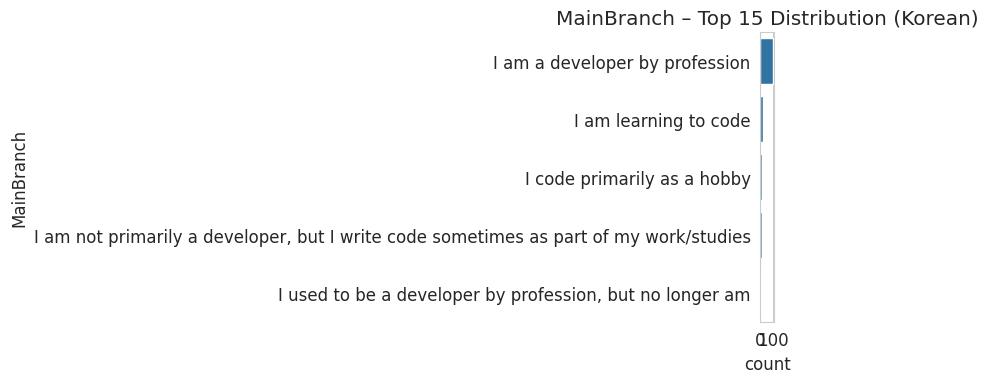

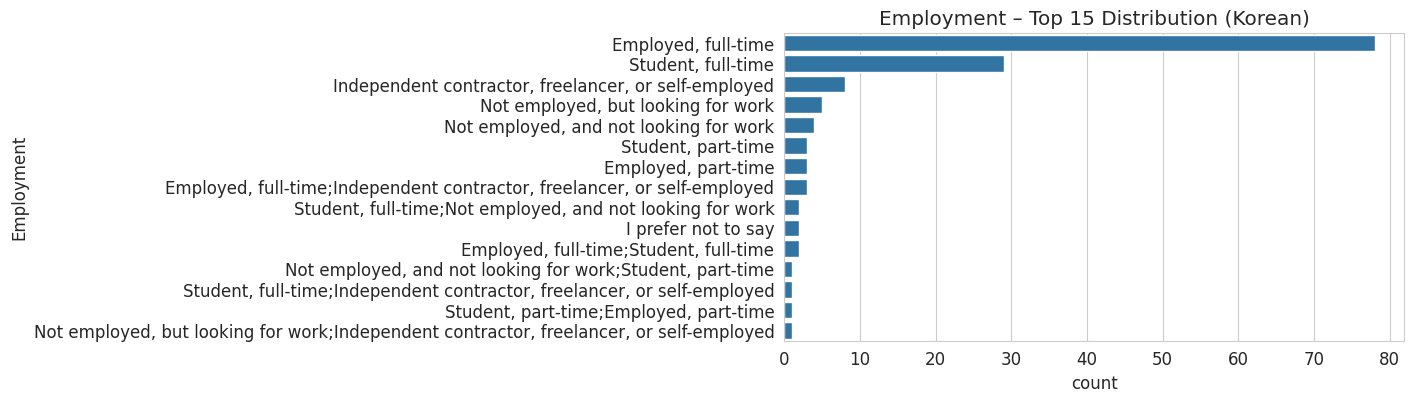

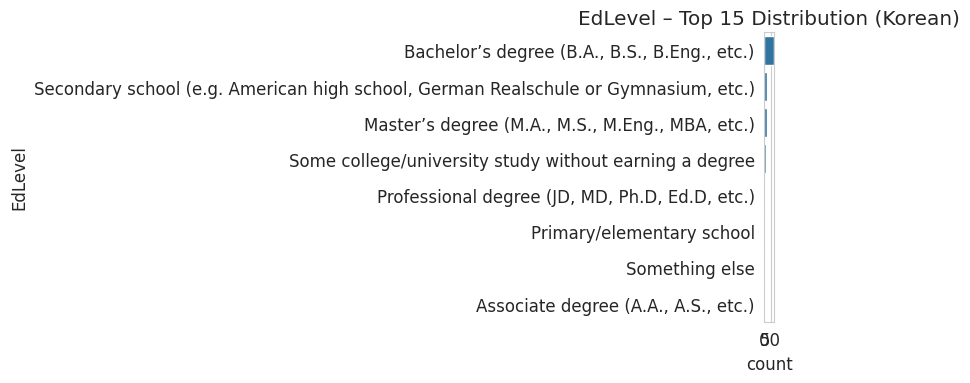

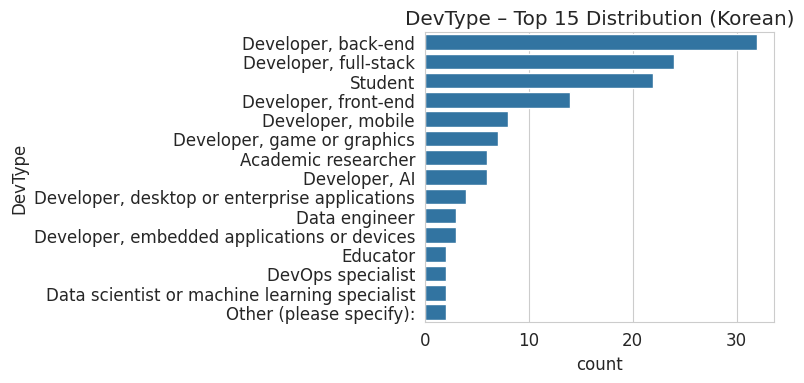

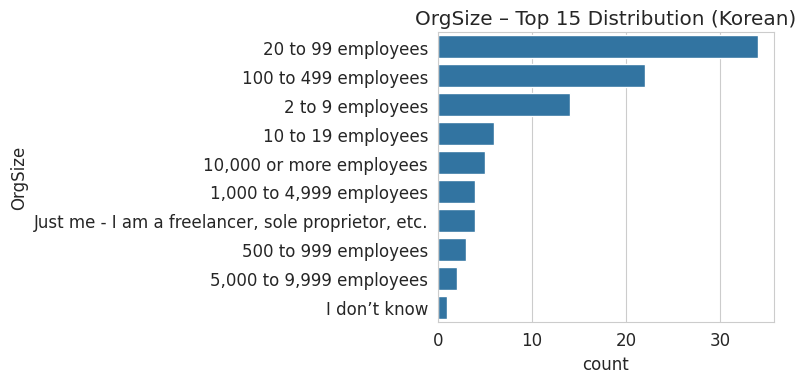

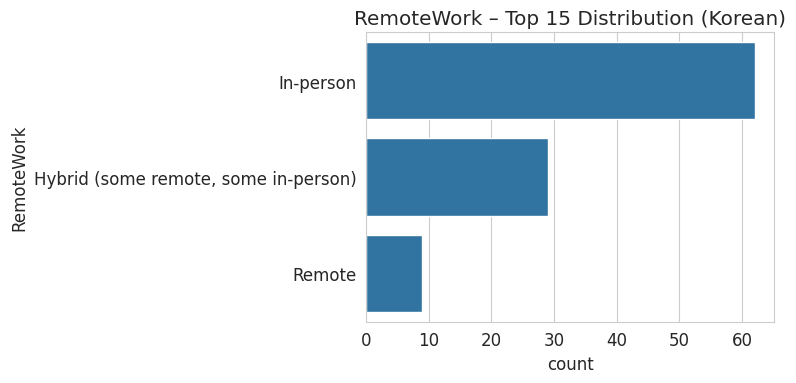

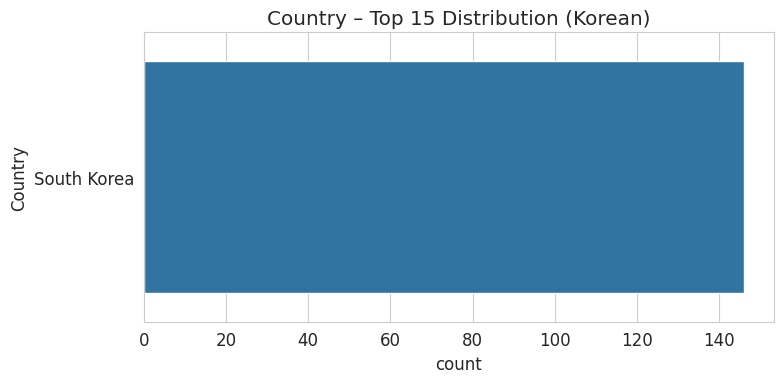

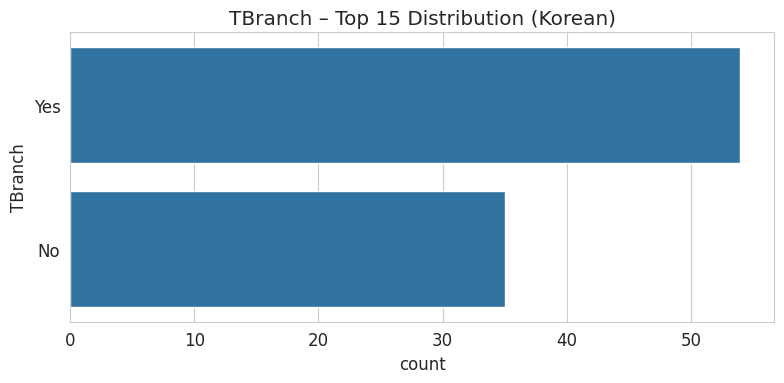

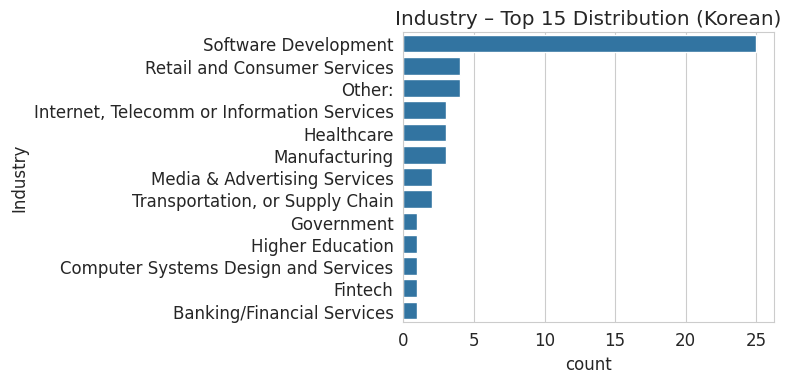

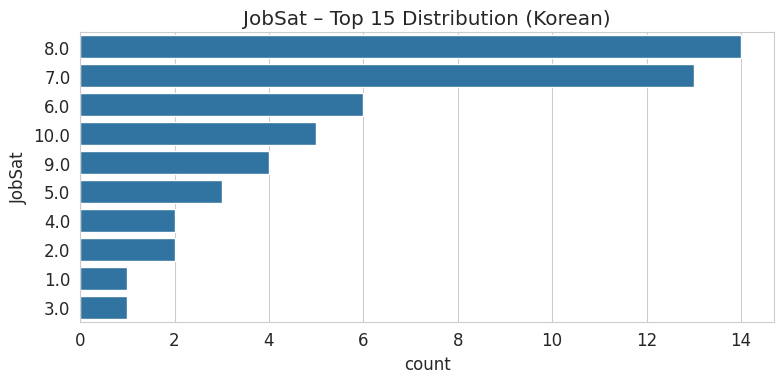

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 주요 범주형 열 목록
cat_cols = [
    "MainBranch", "Employment", "EdLevel", "DevType", "OrgSize",
    "RemoteWork", "Country", "TBranch", "Industry", "JobSat"
]

# 각 열의 Top 15 값에 대해 countplot 생성
for col in cat_cols:
    if col not in df_kr.columns:
        print(f"⚠️ 컬럼 {col} 이 데이터프레임에 없습니다.")
        continue

    plt.figure(figsize=(8, 4))
    order = df_kr[col].value_counts().head(15).index
    sns.countplot(data=df_kr, y=col, order=order)
    plt.title(f"{col} – Top 15 Distribution (Korean)")
    plt.tight_layout()
    plt.show()

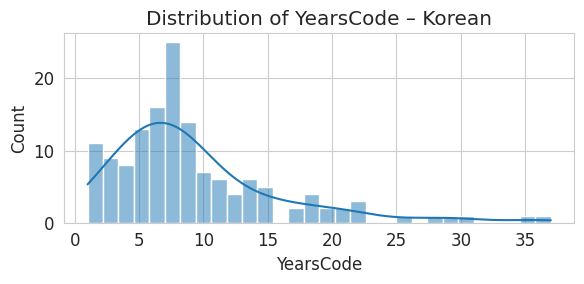

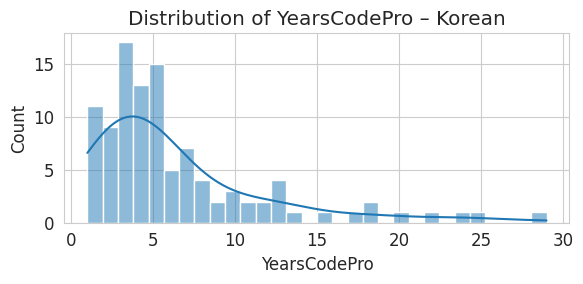

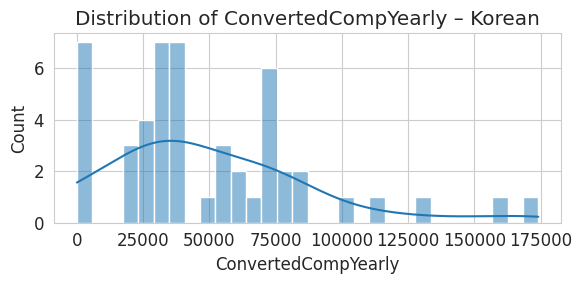

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 숫자형 변환 (문자열 → 숫자, 실패 시 NaN)
for col in ["YearsCode", "YearsCodePro", "ConvertedCompYearly"]:
    df_kr[col] = pd.to_numeric(df_kr[col], errors="coerce")

num_cols = ["YearsCode", "YearsCodePro", "ConvertedCompYearly"]
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df_kr[col].dropna(), bins=30, kde=True)
    plt.title(f"Distribution of {col} – Korean")
    plt.tight_layout()
    plt.show()

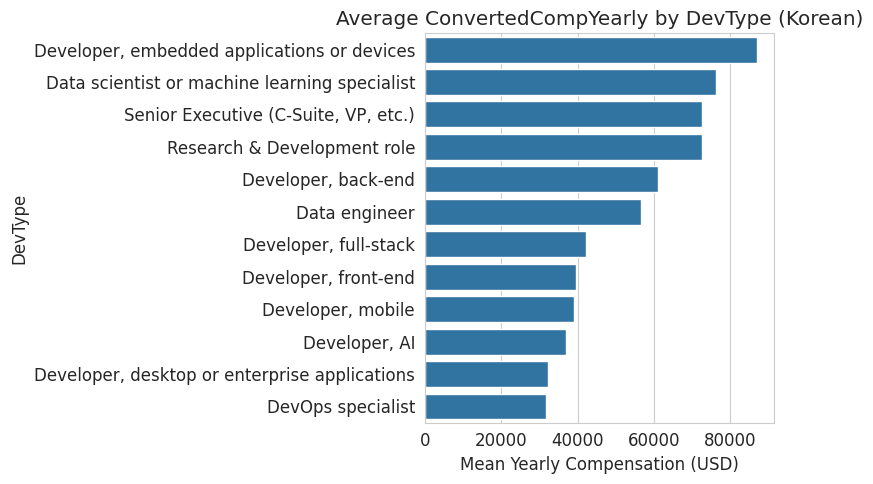

In [26]:
# 📌 [셀 7] DevType (직무 유형)별 평균 연봉 (한국 학생 대상)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# DevType이 세미콜론(;)으로 구분된 다중 선택 항목이므로 분리 처리
dev_df = df_kr[['DevType', 'ConvertedCompYearly']].dropna()

# 세미콜론으로 분리하여 explode
dev_df = dev_df.assign(DevType=dev_df['DevType'].str.split(';')).explode('DevType')
dev_df['DevType'] = dev_df['DevType'].str.strip()  # 앞뒤 공백 제거

# 평균 연봉 계산
devtype_salary = (
    dev_df.groupby('DevType')['ConvertedCompYearly']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

# 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x=devtype_salary.values, y=devtype_salary.index)
plt.title("Average ConvertedCompYearly by DevType (Korean)")
plt.xlabel("Mean Yearly Compensation (USD)")
plt.tight_layout()
plt.show()

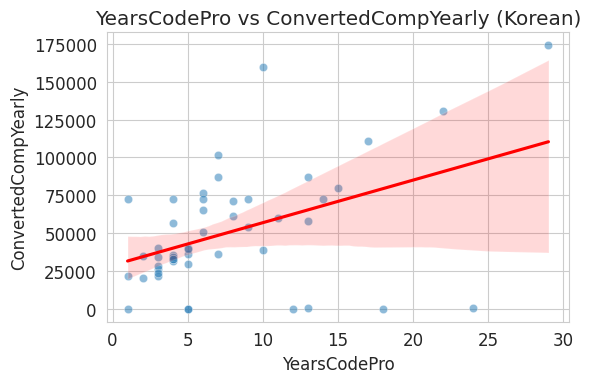

In [27]:
# 📌 [셀 4] 경력 연차 vs 연봉 – 산점도 + 회귀선 (한국 학생)

plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df_kr,
    x="YearsCodePro",
    y="ConvertedCompYearly",
    alpha=0.5
)
sns.regplot(
    data=df_kr,
    x="YearsCodePro",
    y="ConvertedCompYearly",
    scatter=False,
    color="red"
)
plt.title("YearsCodePro vs ConvertedCompYearly (Korean)")
plt.tight_layout()
plt.show()


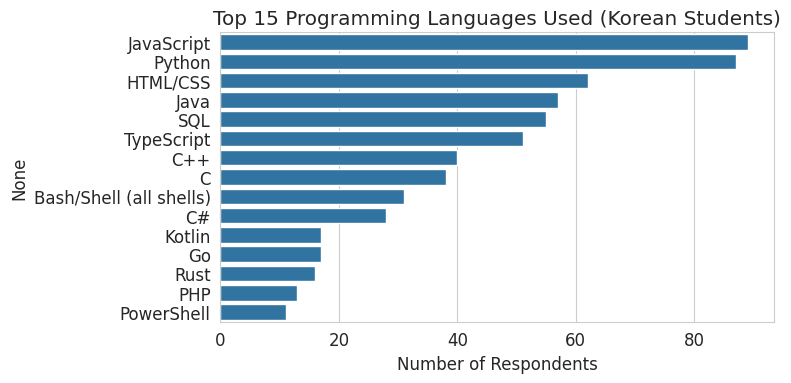

In [28]:
# 📌 [셀 8] 한국 학생 대상 – 사용 경험 있는 프로그래밍 언어(LanguageHaveWorkedWith) 분석

from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns

# LanguageHaveWorkedWith 컬럼에서 세미콜론 기준으로 언어 분해
lang_series = df_kr['LanguageHaveWorkedWith'].dropna().apply(
    lambda x: [lang.strip() for lang in x.split(';')]
)

# MultiLabelBinarizer로 One-hot 인코딩
mlb = MultiLabelBinarizer()
lang_matrix = mlb.fit_transform(lang_series)

# 결과를 DataFrame으로 변환
lang_df = pd.DataFrame(lang_matrix, columns=mlb.classes_)

# 언어별 총 응답자 수 집계
top_langs = lang_df.sum().sort_values(ascending=False).head(15)

# 시각화
plt.figure(figsize=(8, 4))
sns.barplot(x=top_langs.values, y=top_langs.index)
plt.title("Top 15 Programming Languages Used (Korean Students)")
plt.xlabel("Number of Respondents")
plt.tight_layout()
plt.show()


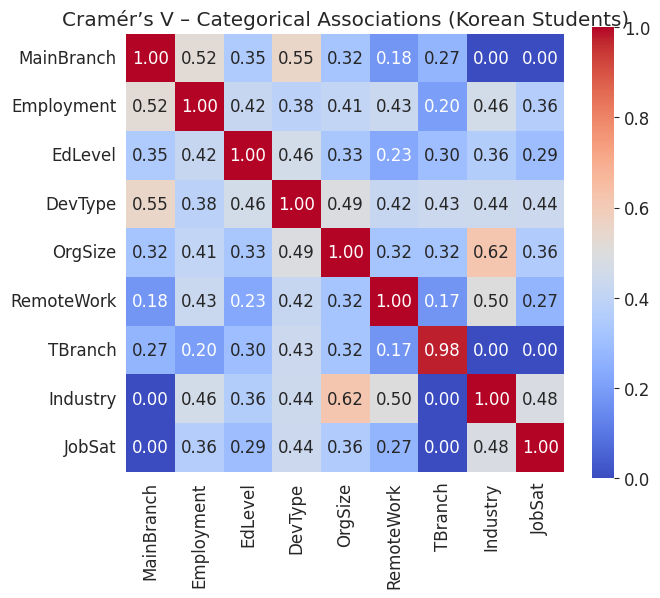

In [29]:
from scipy.stats import chi2_contingency
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Cramér's V 계산 함수
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.size == 0:
        return np.nan
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1) or 1)))

# 분석할 주요 범주형 열 목록
cat_cols = ['MainBranch', 'Employment', 'EdLevel', 'DevType', 'OrgSize', 'RemoteWork', 'TBranch', 'Industry', 'JobSat']

# Cramér’s V 매트릭스 계산
assoc = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for i in cat_cols:
    for j in cat_cols:
        assoc.loc[i, j] = cramers_v(df_kr[i], df_kr[j])

# 시각화
plt.figure(figsize=(7,6))
sns.heatmap(assoc, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Cramér’s V – Categorical Associations (Korean Students)")
plt.tight_layout()
plt.show()